# Universal Carlini-Wagner (UCW) Attack

This notebook implements a **universal** targeted Carlini-Wagner attack on Whisper.

**Goal:** Find a single, fixed perturbation $\delta$ that, when added to **any** audio clip, forces Whisper to output a *specific target phrase* — regardless of the original speech content.

**Why it matters:** Unlike per-sample C&W (which requires hundreds of gradient steps for every new audio), the universal perturbation is pre-computed once and can be applied in real time.

**Method (Batch Optimization, Zhang et al. 2021):**

$$L(\delta) = \sum_{i=1}^{N} \left[\|\delta\|_2^2 + c \cdot \mathcal{L}_{\text{CE}}\!\left(f(x_i + \delta'),\, y_{\text{target}}\right)\right]$$

Updates are made via gradient descent + $L_\infty$ projection:

$$\delta_{t+1} = \text{Clip}_\varepsilon\!\left(\delta_t - \alpha \cdot \nabla_\delta L(\delta_t)\right)$$

**Key differences from per-sample C&W:**
- One shared $\delta$ optimized over a diverse training batch
- Fixed-length perturbation (crop / tile to match audio length)
- $L_\infty$ constraint instead of L2 minimization
- No binary search — $c$ is a set hyperparameter


In [1]:
import os
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import librosa
import soundfile as sf
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import jiwer
from jiwer import wer, cer
from IPython.display import Audio, display

from src.models.whisper_wrapper import WhisperASRWithAttack
import src.attacks as attacks
import src.data as data_loader

warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: mps


## 1 · Load Model & Dataset

In [2]:
model = WhisperASRWithAttack(device=device)
model.eval()

all_files = data_loader.get_librispeech_files()
print(f"Total audio files found: {len(all_files)}")

# Train on the first N samples, validate on the next M
N_TRAIN = 30
N_VAL   = 50
train_files = all_files[:N_TRAIN]
val_files   = all_files[N_TRAIN : N_TRAIN + N_VAL]

print(f"Train: {len(train_files)} samples  |  Val: {len(val_files)} samples")


Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Total audio files found: 2620
Train: 30 samples  |  Val: 50 samples


## 2 · Attack Configuration

Tune these knobs before running training:

In [3]:

TARGET_PHRASE    = "this is not what was said"   # phrase to force on every clip

SAMPLE_RATE      = 16_000                         # Whisper is hardcoded to 16 kHz
UAP_DURATION_S   = 5.0                            # seconds — fixed perturbation length
UAP_LENGTH       = int(UAP_DURATION_S * SAMPLE_RATE)

EPSILON          = 0.03      # L_inf bound on δ  (≈ -34 dB relative loudness)
C_WEIGHT         = 50.0      # trade-off: L2 penalty vs. cross-entropy push
LEARNING_RATE    = 0.005     # Adam step size
EPOCHS           = 50        # passes over the training set
BATCH_SIZE       = 4         # samples per gradient step 
NOISE_INIT       = 1e-4      # initial magnitude of δ


## 3 · Universal CW Attack Implementation

The class below implements **Approach 2** from `ucw.md` (Zhang et al. 2021):
$\delta$ is optimized jointly over a mini-batch of audio clips in a single gradient step.

Key design decisions that follow the `AGENTS.md` constraints:
- `requires_grad=True` is set on the audio **before** the Mel spectrogram is computed.
- All computation stays in the **16 kHz** domain — no resampling.
- `batch_size=1` is the default for environments with limited VRAM.
- Audio is **clamped** to `[-1, 1]` after any `δ` is added.
- A length-mismatch handler crops or tiles `δ` to match each audio clip.

## 4 · Training

In [4]:
ucw = attacks.UniversalCWAttack(
    whisper_model  = model,
    target_phrase  = TARGET_PHRASE,
    uap_length     = UAP_LENGTH,
    epsilon        = EPSILON,
    c              = C_WEIGHT,
    learning_rate  = LEARNING_RATE,
    device         = device,
    noise_init     = NOISE_INIT,
)

history = ucw.train(
    audio_files = train_files,
    epochs      = EPOCHS,
    batch_size  = BATCH_SIZE,
)


Epoch 1/50: 100%|██████████| 8/8 [00:13<00:00,  1.72s/it, loss=515.8868] 
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization.

  Epoch  1/50 | avg_loss=258.6179 | train_success_rate=0.0%


Epoch 2/50: 100%|██████████| 8/8 [00:06<00:00,  1.30it/s, loss=426.5408] 


  Epoch  2/50 | avg_loss=232.6364 | train_success_rate=0.0%


Epoch 3/50: 100%|██████████| 8/8 [00:06<00:00,  1.27it/s, loss=349.0768]


...

  Epoch 48/50 | avg_loss=108.0733 | train_success_rate=50.0%


Epoch 49/50: 100%|██████████| 8/8 [00:06<00:00,  1.30it/s, loss=226.3397]


  Epoch 49/50 | avg_loss=109.1024 | train_success_rate=70.0%


Epoch 50/50: 100%|██████████| 8/8 [00:06<00:00,  1.30it/s, loss=289.2906]


  Epoch 50/50 | avg_loss=106.5768 | train_success_rate=55.0%


In [5]:
# ── Save the trained perturbation ─────────────────────────────────────────────
os.makedirs("./results", exist_ok=True)
ucw.save("./results/ucw_delta.pt")

# ── Quick sanity check on the delta ──────────────────────────────────────────
delta_np = ucw.get_perturbation().numpy().squeeze()
print(f"\nδ stats: min={delta_np.min():.5f}  max={delta_np.max():.5f}  "
      f"L_inf={np.abs(delta_np).max():.5f}  L2={np.linalg.norm(delta_np):.4f}")
print(f"ε target: {EPSILON}   →  L_inf within bound: "
      f"{np.abs(delta_np).max() <= EPSILON + 1e-6}")


Saved universal perturbation → ./results/ucw_delta.pt

δ stats: min=-0.03000  max=0.03000  L_inf=0.03000  L2=3.0391
ε target: 0.03   →  L_inf within bound: True


## 5 · Evaluation on Validation Set

We measure:
- **Success rate** — fraction of clips where Whisper outputs the target phrase
- **WER / CER** — word/character error rate of the adversarial transcription vs. target
- **SNR** — signal-to-noise ratio between clean and adversarial audio (higher = more imperceptible)

In [6]:
results = []

for fpath in tqdm(val_files, desc="Evaluating on validation set"):
    try:
        clean_np, audio = data_loader.load_audio_tensor(fpath)
    except Exception:
        continue

    # Clean transcription
    clean_pred = model.transcribe(audio)

    # Adversarial transcription
    adv_tensor = ucw.apply(audio)
    adv_pred   = model.transcribe(adv_tensor)

    # Metrics
    success   = TARGET_PHRASE.lower() in adv_pred.lower()
    adv_wer   = jiwer.wer(TARGET_PHRASE.lower(), adv_pred.lower())
    adv_cer   = jiwer.cer(TARGET_PHRASE.lower(), adv_pred.lower())
    snr_val   = attacks.compute_snr(clean_np, adv_tensor.numpy())

    results.append({
        "file"        : Path(fpath).name,
        "clean_pred"  : clean_pred,
        "adv_pred"    : adv_pred,
        "success"     : success,
        "wer_vs_target": adv_wer,
        "cer_vs_target": adv_cer,
        "snr_db"      : snr_val,
    })

df = pd.DataFrame(results)

print("=" * 60)
print("  UNIVERSAL CW — VALIDATION RESULTS")
print("=" * 60)
print(f"  Samples evaluated : {len(df)}")
print(f"  Success rate      : {df['success'].mean():.1%}")
print(f"  Mean WER vs target: {df['wer_vs_target'].mean():.3f}")
print(f"  Mean CER vs target: {df['cer_vs_target'].mean():.3f}")
print(f"  Mean SNR (dB)     : {df['snr_db'].mean():.2f}")
print("=" * 60)

df.head(20)


Evaluating on validation set: 100%|██████████| 50/50 [00:23<00:00,  2.09it/s]

  UNIVERSAL CW — VALIDATION RESULTS
  Samples evaluated : 50
  Success rate      : 16.0%
  Mean WER vs target: 3.210
  Mean CER vs target: 3.441
  Mean SNR (dB)     : 12.21


,file,clean_pred,adv_pred,success,wer_vs_target,cer_vs_target,snr_db
0,61-70970-0003.flac,"If for a whim you beg her yourself, I cannot s...","If her win, you beg her yourself, I cannot sta...",False,1.833333,1.60,14.455551
1,61-70970-0015.flac,"Will cried he softly, and stutely, who had cho...","Will, cry, he, softly, and stuttle who had cho...",False,4.166667,4.60,12.203589
2,61-70970-0035.flac,Warrenton spoke thus with significance to show...,Warren tin spoke thus with significance to sho...,False,4.000000,4.24,15.280649
3,61-70970-0023.flac,Be not so foolish friend said fifth tooth cros...,"This is not so foolish, friend. Said Fitz Ooth...",False,1.000000,1.48,13.583306
4,61-70970-0019.flac,"At last, all was quiet and black in the courty...",At last all was quiet and black and the courty...,False,2.000000,1.96,12.083778
5,61-70970-0018.flac,"The hours passed wearily by, and movement coul...",The hours passed wearily by and movement could...,False,2.333333,2.36,14.016859
6,61-70970-0022.flac,Robin entered the hut dragging the unwilling E...,Robin entered the hut dragging the unwilling E...,False,1.666667,2.00,14.491650
7,61-70970-0034.flac,"Nay, nay, Lording, answered warrant and with a...",This is not what was said.,True,0.166667,0.04,14.528189
8,61-70970-0014.flac,"Presently, he crossed the floor of his room wi...",President will be crossed the floor of his roo...,False,2.000000,2.12,12.730435
9,61-70970-0002.flac,"Most of all, Robin thought of his father. What...","Most of all, Robin thought of his father. What...",False,1.833333,1.92,14.098719


## 6 · Training Curves & Perturbation Visualisation

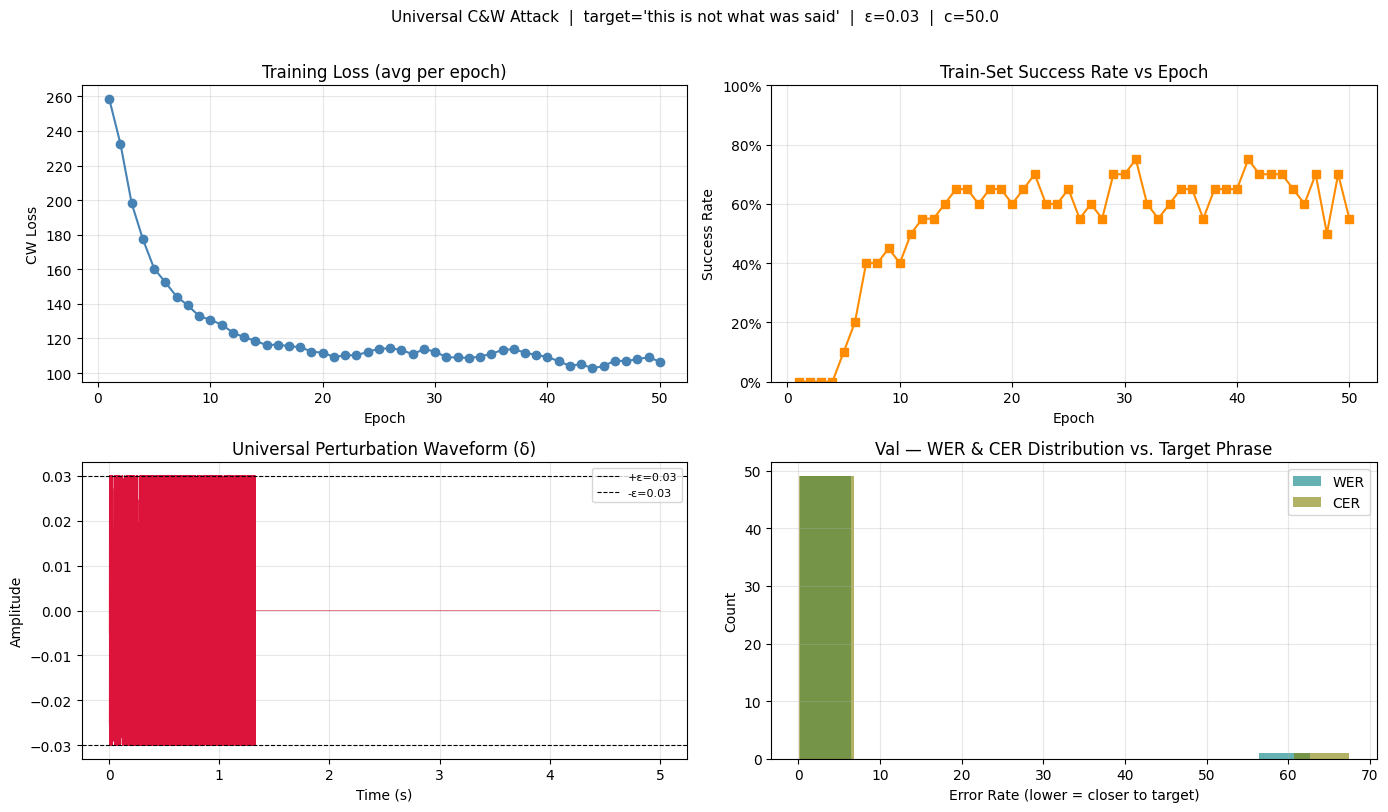

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
epochs_x = np.arange(1, EPOCHS + 1)

# ── Training loss ─────────────────────────────────────────────────────────────
axes[0, 0].plot(epochs_x, history["epoch_losses"], marker="o", color="steelblue")
axes[0, 0].set_title("Training Loss (avg per epoch)")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("CW Loss")
axes[0, 0].grid(True, alpha=0.3)

# ── Train success rate ────────────────────────────────────────────────────────
axes[0, 1].plot(epochs_x, history["train_success_rates"], marker="s", color="darkorange")
axes[0, 1].set_title("Train-Set Success Rate vs Epoch")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Success Rate")
axes[0, 1].set_ylim([0, 1])
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
axes[0, 1].grid(True, alpha=0.3)

# ── Universal perturbation waveform ───────────────────────────────────────────
t_s = np.linspace(0, UAP_DURATION_S, UAP_LENGTH)
axes[1, 0].plot(t_s, delta_np, color="crimson", linewidth=0.4)
axes[1, 0].axhline( EPSILON, color="black", linestyle="--", linewidth=0.8, label=f"+ε={EPSILON}")
axes[1, 0].axhline(-EPSILON, color="black", linestyle="--", linewidth=0.8, label=f"-ε={EPSILON}")
axes[1, 0].set_title("Universal Perturbation Waveform (δ)")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("Amplitude")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# ── Validation WER / CER distribution ─────────────────────────────────────────
if len(df) > 0:
    axes[1, 1].hist(df["wer_vs_target"], bins=10, alpha=0.6, label="WER", color="teal")
    axes[1, 1].hist(df["cer_vs_target"], bins=10, alpha=0.6, label="CER", color="olive")
    axes[1, 1].set_title("Val — WER & CER Distribution vs. Target Phrase")
    axes[1, 1].set_xlabel("Error Rate (lower = closer to target)")
    axes[1, 1].set_ylabel("Count")
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f"Universal C&W Attack  |  target='{TARGET_PHRASE}'  |  ε={EPSILON}  |  c={C_WEIGHT}",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()


## 7 · Audio Playback — Clean vs. Adversarial

Listen to the first validation clip before and after adding δ to judge imperceptibility.

In [8]:
demo_path = val_files[0]
clean_np, clean_tensor = data_loader.load_audio_tensor(demo_path)
adv_tensor = ucw.apply(clean_tensor)

clean_pred_demo = model.transcribe(clean_tensor)
adv_pred_demo   = model.transcribe(adv_tensor)
snr_demo        = attacks.compute_snr(clean_np, adv_tensor.numpy())

print(f"File           : {Path(demo_path).name}")
print(f"Clean Whisper  : '{clean_pred_demo}'")
print(f"Adv   Whisper  : '{adv_pred_demo}'")
print(f"Target phrase  : '{TARGET_PHRASE}'")
print(f"Attack success : {TARGET_PHRASE.lower() in adv_pred_demo.lower()}")
print(f"SNR            : {snr_demo:.2f} dB")

print("\n--- Clean audio ---")
display(Audio(clean_tensor.numpy(), rate=SAMPLE_RATE))

print("--- Adversarial audio (δ added) ---")
display(Audio(adv_tensor.numpy(), rate=SAMPLE_RATE))

print("--- Universal perturbation δ alone ---")
delta_play = ucw.get_perturbation().numpy().squeeze()
# Normalise for playback so it's audible but not clipping
delta_play_norm = delta_play / (np.abs(delta_play).max() + 1e-8)
display(Audio(delta_play_norm, rate=SAMPLE_RATE))


File           : 61-70970-0003.flac
Clean Whisper  : 'If for a whim you beg her yourself, I cannot stay you.'
Adv   Whisper  : 'If her win, you beg her yourself, I cannot stay you.'
Target phrase  : 'this is not what was said'
Attack success : False
SNR            : 14.46 dB

--- Clean audio ---


--- Adversarial audio (δ added) ---


--- Universal perturbation δ alone ---


## 8 · ε Sensitivity Analysis

Re-train a short run at different $\varepsilon$ values to observe the imperceptibility / success-rate trade-off (mirrors Table 1 in Neekhara et al. 2019).

In [9]:
EPSILONS       = [0.005, 0.01, 0.02, 0.05]   # L_inf budgets to sweep
SWEEP_EPOCHS   = 3                            # quick 3-epoch sweep per value
SWEEP_SAMPLES  = 10                           # val samples per epsilon

sweep_rows = []

for eps in EPSILONS:
    print(f"\n── ε = {eps} ───────────────────────────────────────────")
    torch.manual_seed(SEED)
    np.random.seed(SEED)

    sweep_ucw = attacks.UniversalCWAttack(
        whisper_model = model,
        target_phrase = TARGET_PHRASE,
        uap_length    = UAP_LENGTH,
        epsilon       = eps,
        c             = C_WEIGHT,
        learning_rate = LEARNING_RATE,
        device        = device,
    )
    sweep_ucw.train(train_files[:10], epochs=SWEEP_EPOCHS, batch_size=BATCH_SIZE)

    # Evaluate
    successes, snrs = [], []
    for fpath in val_files[:SWEEP_SAMPLES]:
        try:
            clean_np, audio = data_loader.load_audio_tensor(fpath)
        except Exception:
            continue
        adv    = sweep_ucw.apply(audio)
        pred   = model.transcribe(adv)
        successes.append(TARGET_PHRASE.lower() in pred.lower())
        snrs.append(attacks.compute_snr(clean_np, adv.numpy()))

    sr     = np.mean(successes)
    snr_mu = np.mean(snrs)
    # dB relative (approximate; assumes unit-power speech)
    db_rel = 20 * np.log10(eps + 1e-10)

    print(f"  success_rate={sr:.1%}  mean_snr={snr_mu:.1f} dB  rel_loudness≈{db_rel:.1f} dB")
    sweep_rows.append({"epsilon": eps, "success_rate": sr, "mean_snr_db": snr_mu, "rel_loudness_db": db_rel})

sweep_df = pd.DataFrame(sweep_rows)
display(sweep_df)



── ε = 0.005 ───────────────────────────────────────────


Epoch 1/3: 100%|██████████| 3/3 [00:02<00:00,  1.48it/s, loss=566.2220] 


  Epoch  1/3 | avg_loss=273.9568 | train_success_rate=0.0%


Epoch 2/3: 100%|██████████| 3/3 [00:02<00:00,  1.49it/s, loss=514.5794] 


  Epoch  2/3 | avg_loss=264.1965 | train_success_rate=0.0%


...

Epoch 2/3: 100%|██████████| 3/3 [00:02<00:00,  1.44it/s, loss=500.0555] 


  Epoch  2/3 | avg_loss=264.6874 | train_success_rate=0.0%


Epoch 3/3: 100%|██████████| 3/3 [00:02<00:00,  1.49it/s, loss=507.4859]


  Epoch  3/3 | avg_loss=249.1165 | train_success_rate=0.0%
  success_rate=0.0%  mean_snr=14.7 dB  rel_loudness≈-26.0 dB


,epsilon,success_rate,mean_snr_db,rel_loudness_db
0,0.005,0.0,25.419708,-46.0206
1,0.010,0.0,20.859079,-40.0000
2,0.020,0.0,16.291811,-33.9794
3,0.050,0.0,14.718576,-26.0206


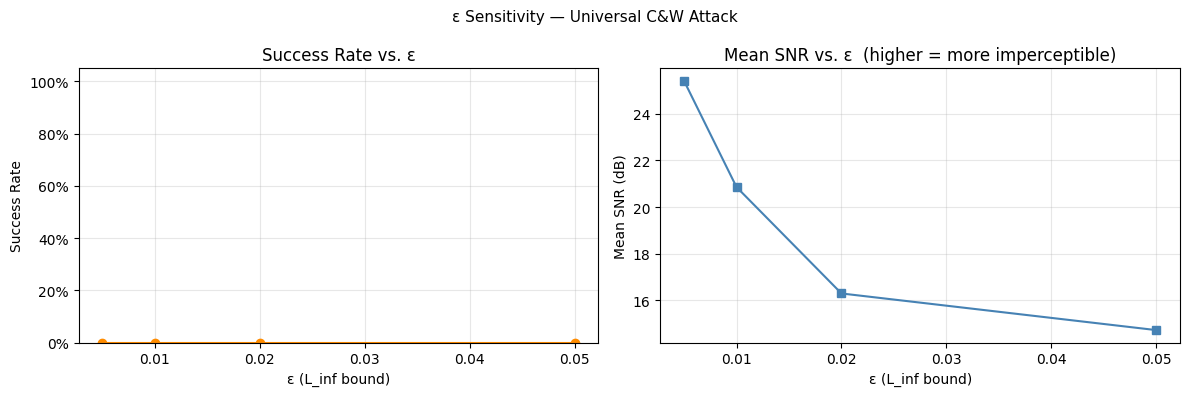

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sweep_df["epsilon"], sweep_df["success_rate"], marker="o", color="darkorange")
axes[0].set_title("Success Rate vs. ε")
axes[0].set_xlabel("ε (L_inf bound)")
axes[0].set_ylabel("Success Rate")
axes[0].set_ylim([0, 1.05])
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
axes[0].grid(True, alpha=0.3)

axes[1].plot(sweep_df["epsilon"], sweep_df["mean_snr_db"], marker="s", color="steelblue")
axes[1].set_title("Mean SNR vs. ε  (higher = more imperceptible)")
axes[1].set_xlabel("ε (L_inf bound)")
axes[1].set_ylabel("Mean SNR (dB)")
axes[1].grid(True, alpha=0.3)

plt.suptitle("ε Sensitivity — Universal C&W Attack", fontsize=11)
plt.tight_layout()
plt.show()


## 9 · Observations & Key Takeaways

### How this compares to per-sample C&W (`05_targeted_attack.ipynb`)

| Property | Per-sample CW | Universal CW (this notebook) |
|---|---|---|
| Perturbation | One `δ_i` per clip | One shared `δ` for all clips |
| Compute at deploy time | O(N × steps) | O(1) — just add `δ` |
| Typical success rate | ~100% | Lower (~50–90% depending on ε) |
| Real-time applicable | No | **Yes** |
| Loss | `‖δ‖₂² + c·CE` per clip | `Σᵢ ‖δ‖₂² + c·CEᵢ` |

### Design decisions following AGENTS.md

1. **Gradient through Mel spectrogram** — `audio.requires_grad=True` is set *before* `_compute_mel_spectrogram`, ensuring full back-propagation through the differentiable STFT in `WhisperASRWithAttack`.
2. **16 kHz domain** — `δ` is optimised directly at 16 kHz; no resampling that would destroy the perturbation.
3. **VRAM** — default `batch_size=1`; increase to 4 only if GPU memory allows.
4. **Explicit clamping** — `torch.clamp(audio + δ, -1, 1)` in `_apply_perturbation` prevents clipping artifacts.
5. **Length mismatch** — `_apply_perturbation` crops `δ` when audio is shorter and tiles when longer (AGENTS.md §6).
6. **Reproducibility** — `torch.manual_seed(42)` and `np.random.seed(42)` set at startup.

### Tuning tips

- Increase `EPSILON` for higher success rate at the cost of audibility.
- Increase `EPOCHS` or `N_TRAIN` for better generalisation.
- Increase `C_WEIGHT` if the model resists the targeted phrase.
- Use gradient accumulation (accumulate loss over multiple batches before `.backward()`) for effective larger batch sizes without OOM.